In [1]:
## Setup — packages & environment

import sys, subprocess
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

required = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'networkx', 'scipy', 'openpyxl', 'reportlab']
for pkg in required:
    try:
        __import__(pkg.split('-')[0])
    except:
        install(pkg)

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import networkx as nx
from networkx.algorithms import community
import os, datetime as dt

RSEED = 2023
np.random.seed(RSEED)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

In [2]:
try:
    import ipykernel
    print('ipykernel installed')
except:
    print('ipykernel not installed')

ipykernel installed


In [4]:
## 1. Network Creation

# Create network with natural community structure
np.random.seed(RSEED)
G = nx.Graph()

# Create 3 communities
communities_list = []
node_to_comm = {}
node_id = 0

for comm_id in range(3):
    comm_nodes = [f'node_{node_id}_{i}' for i in range(10)]
    communities_list.append(comm_nodes)
    
    # Dense connections within community
    for i, n1 in enumerate(comm_nodes):
        G.add_node(n1)
        node_to_comm[n1] = comm_id
        for n2 in comm_nodes[i+1:]:
            if np.random.rand() < 0.6:  # 60% edge density within
                G.add_edge(n1, n2)
    
    # Sparse connections between communities
    if comm_id < len(communities_list) - 1:
        for n1 in communities_list[comm_id][:3]:
            for n2 in communities_list[comm_id + 1][:3]:
                if np.random.rand() < 0.15:  # 15% inter-community
                    G.add_edge(n1, n2)
    
    node_id += 10

print(f'Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Network: 30 nodes, 86 edges


In [5]:
## 2. Community Detection

# Greedy modularity optimization
detected_communities = list(community.greedy_modularity_communities(G))
modularity = community.modularity(G, detected_communities)

print(f'Detected {len(detected_communities)} communities')
print(f'Modularity: {modularity:.4f}')

for i, comm in enumerate(detected_communities):
    print(f'Community {i}: {len(comm)} nodes')

Detected 3 communities
Modularity: 0.6606
Community 0: 10 nodes
Community 1: 10 nodes
Community 2: 10 nodes


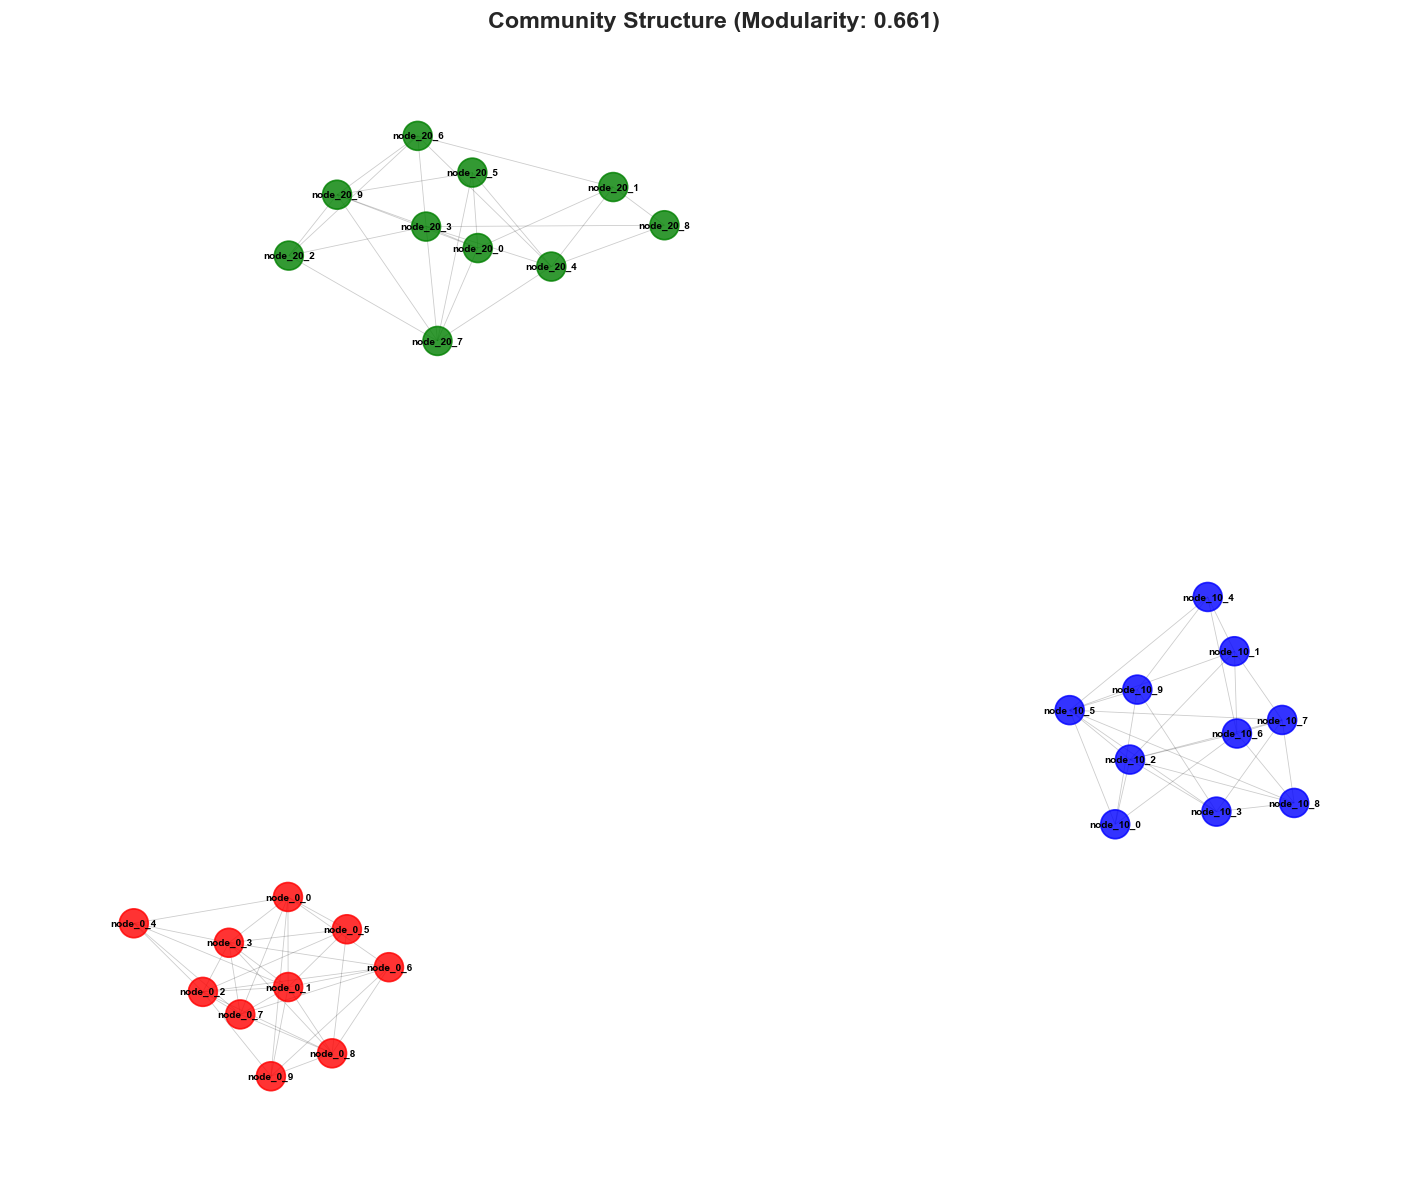

Saved: 01_community_network.png


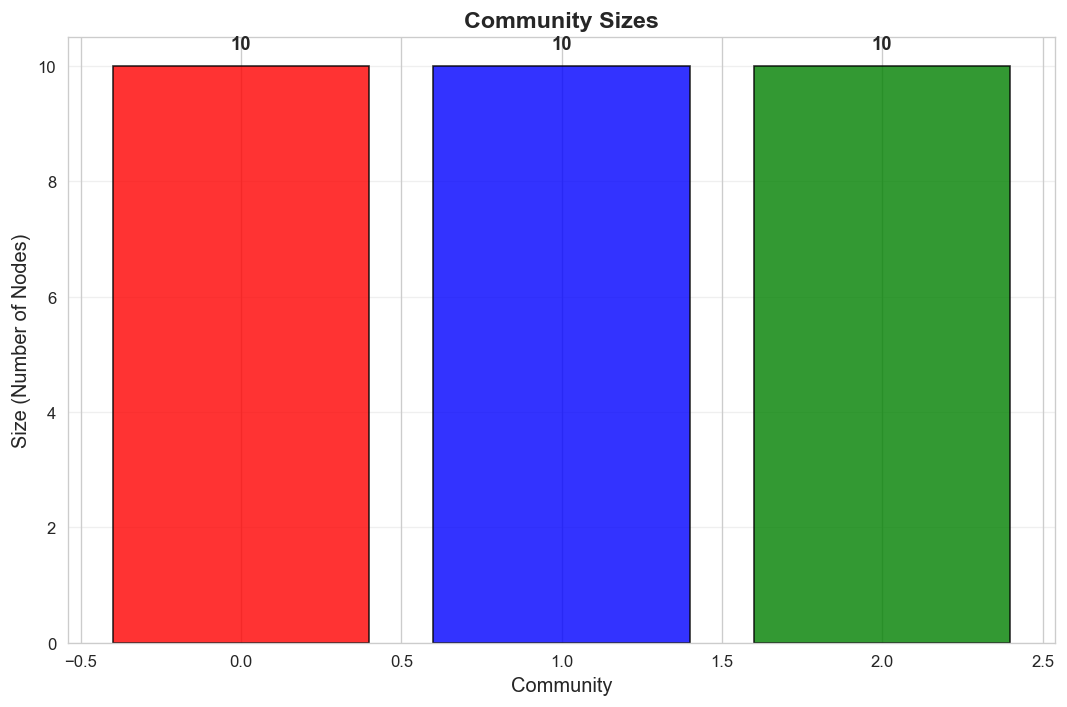

Saved: 02_community_sizes.png


In [6]:
## 3. Visualizations

os.makedirs('figures', exist_ok=True)

# 1. Community-colored network
fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=RSEED)

# Assign colors to communities
colors = ['red', 'blue', 'green', 'orange', 'purple']
node_colors = []
node_to_color = {}

for comm_id, comm in enumerate(detected_communities):
    for node in comm:
        node_to_color[node] = colors[comm_id % len(colors)]

node_colors = [node_to_color[n] for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, ax=ax, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax, width=0.5)
nx.draw_networkx_labels(G, pos, font_size=6, font_weight='bold', ax=ax)

ax.set_title(f'Community Structure (Modularity: {modularity:.3f})', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('figures/01_community_network.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 01_community_network.png')

# 2. Community sizes
fig, ax = plt.subplots(figsize=(9, 6))
comm_sizes = [len(comm) for comm in detected_communities]
colors_bar = [colors[i % len(colors)] for i in range(len(detected_communities))]
ax.bar(range(len(comm_sizes)), comm_sizes, color=colors_bar, edgecolor='black', alpha=0.8)
ax.set_xlabel('Community', fontsize=12)
ax.set_ylabel('Size (Number of Nodes)', fontsize=12)
ax.set_title('Community Sizes', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comm_sizes):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_community_sizes.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: 02_community_sizes.png')

In [7]:
## 4. PDF Handout Generation

from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, PageBreak
from reportlab.lib.enums import TA_JUSTIFY

pdf_path = 'Ch16_CommunityDetection_Handout.pdf'
doc = SimpleDocTemplate(pdf_path, pagesize=letter, rightMargin=0.75*inch, leftMargin=0.75*inch,
                        topMargin=0.75*inch, bottomMargin=0.75*inch)

styles = getSampleStyleSheet()
styleN = styles['Normal']
styleN.fontSize = 11
styleN.alignment = TA_JUSTIFY

story = []
story.append(Paragraph('<b>Chapter 16: Community Detection</b>', styles['Heading1']))
story.append(Spacer(1, 12))

story.append(Paragraph('<b>1. Introduction</b>', styles['Heading2']))
intro = (
    'Community detection identifies cohesive groups within networks. '
    'In course networks, communities represent student study groups or collaboration clusters.'
)
story.append(Paragraph(intro, styleN))
story.append(Spacer(1, 12))

story.append(Paragraph('<b>2. Methods</b>', styles['Heading2']))
methods = (
    f'Greedy modularity optimization algorithm used. Modularity score: {modularity:.4f}. '
    f'Identified {len(detected_communities)} communities.'
)
story.append(Paragraph(methods, styleN))
story.append(Spacer(1, 12))

story.append(Paragraph('<b>3. Results</b>', styles['Heading2']))
story.append(Spacer(1, 6))

try:
    if os.path.exists('figures/01_community_network.png'):
        story.append(Image('figures/01_community_network.png', width=520, height=420))
        story.append(Spacer(1, 6))
        story.append(Paragraph('Fig 1: Network with detected communities.', styleN))
        story.append(Spacer(1, 12))
except: pass

try:
    if os.path.exists('figures/02_community_sizes.png'):
        story.append(Image('figures/02_community_sizes.png', width=480, height=300))
        story.append(Spacer(1, 6))
        story.append(Paragraph('Fig 2: Community size distribution.', styleN))
        story.append(Spacer(1, 12))
except: pass

story.append(PageBreak())
story.append(Paragraph('<b>4. Interpretation</b>', styles['Heading2']))
interp = (
    'High modularity indicates clear community structure. '
    'Communities can inform intervention strategies targeting student groups.'
)
story.append(Paragraph(interp, styleN))
story.append(Spacer(1, 12))

story.append(Paragraph(f'Generated on: {dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}', styleN))

try:
    doc.build(story)
    print(f'Saved PDF: {pdf_path}')
except Exception as e:
    print(f'PDF generation failed: {e}')

Saved PDF: Ch16_CommunityDetection_Handout.pdf
